In [1]:
import os, sys
import matplotlib.pyplot as plt
import numpy as np

# Biblioteca y módulos de flopy
import flopy
from flopy.plot.styles import styles

# Extras para mf6 y flopy (módulo creado en este proyecto)
import xmf6

from modflowapi import ModflowApi

In [2]:
init = {
    'sim_name' : "flow",
    'exe_name' : "C:\\Users\\luiggi\\Documents\\GitSites\\xmf6\\mf6\\windows\\mf6",
#    'exe_name' : "../../mf6/macosarm/mf6",
    'sim_ws' : "sandbox1"
}

time = {
    'units': "seconds",
    'nper' : 1,
    'perioddata': [(120.0, 1, 1.0)]
}

ims = {}

gwf = { 
    'modelname': init["sim_name"],
    'model_nam_file': f"{init["sim_name"]}.nam",
    'save_flows': True
}

o_sim = xmf6.gwf.initialize(silent = True, init = init, time = time, ims = ims)

In [3]:
print(o_sim)

sim_name = flow
sim_path = C:\Users\luiggi\Documents\GitSites\xmf6\examples\10_mf6_api\emsdatasets\Test\sandbox1
exe_name = C:\Users\luiggi\Documents\GitSites\xmf6\mf6\windows\mf6

###################
Package mfsim.nam
###################

package_name = mfsim.nam
filename = mfsim.nam
package_type = nam
model_or_simulation_package = simulation
simulation_name = flow


###################
Package flow.tdis
###################

package_name = flow.tdis
filename = flow.tdis
package_type = tdis
model_or_simulation_package = simulation
simulation_name = flow


###################
Package ims_-1
###################

package_name = ims_-1
filename = flow.ims
package_type = ims
model_or_simulation_package = simulation
simulation_name = flow





In [4]:
dis = {
    'length_units' : "centimeters",
    'nlay': 1, 
    'nrow': 1, 
    'ncol': 120,
    'delr': 1.0, 
    'delc': 1.0,
    'top' : 1.0, 
    'botm': 0.0 
}

ic = {
    'strt': 1.0
}

npf = {
    'save_specific_discharge': True,
    'save_saturation' : True,
    'icelltype' : 0,
    'k' : 0.01,
}

chd = {
    'stress_period_data': [[(0, 0, dis['ncol'] - 1), 1.0]],     
}

## Physical parameters
specific_discharge = 0.1  # Specific discharge ($cm s^{-1}$)
source_concentration = 1.0  # Source concentration (unitless)
q   = specific_discharge * dis['delc'] * dis['delr'] * dis['top']
aux = source_concentration

well = {
    'stress_period_data': [[(0, 0, 0), q, aux,]],
    'pname': "WEL-1",
    'save_flows': True,
    'auxiliary' : ["CONCENTRATION"],

}

oc = {
    'budget_filerecord': f"{init['sim_name']}.bud",
    'head_filerecord': f"{init['sim_name']}.hds",
    'saverecord' : [("HEAD", "ALL"), ("BUDGET", "ALL")],

}

o_gwf = xmf6.gwf.build(o_sim, silent = True,
                       gwf = gwf, dis = dis, ic = ic, chd = chd, npf = npf, oc = oc, well = well)

o_sim.write_simulation(silent = True)

In [36]:
if sys.platform == "win32":
    mf6_dll = "libmf6.dll"
elif sys.platform == "darwin":
    mf6_dll = "libmf6.dylib"
else:
    mf6_dll = "libmf6.so"

mf6_dll = os.path.abspath(os.path.join("..", "bin", mf6_dll))
print(sys.platform, ": ", mf6_dll)

win32 :  C:\Users\luiggi\Documents\GitSites\xmf6\examples\10_mf6_api\emsdatasets\bin\libmf6.dll


In [ ]:
mf6_config_file = os.path.join(init['sim_ws'], 'mfsim.nam')
mf6 = ModflowApi(mf6_dll, working_directory=init['sim_ws'])

# initialize the model
mf6.initialize(mf6_config_file)

In [38]:
print("MF6 Input var names :", mf6.get_input_var_names())

MF6 Input var names : ('FLOW/DIS/XC', 'SLN_1/NCOL', 'FLOW/CHD_0/IOUT', 'SLN_1/IMSLINEAR/ID', 'FLOW/CON/JA', '__INPUT__/FLOW/WEL-1/Q', 'TDIS/PERTIMSAV', 'SLN_1/IMSLINEAR/WLU', 'FLOW/DIS/NDIM', 'FLOW/CHD_0/INEWTON', 'SLN_1/IMSLINEAR/IW', 'SLN_1/IMSLINEAR/ARO', 'TDIS/TOPERTIM', 'FLOW/DIS/NODESUSER', 'FLOW/DIS/YC', 'FLOW/IPRFLOW', 'FLOW/NPF/SAT', '__INPUT__/SIM/NAM/TDIS6', 'SLN_1/IMSLINEAR/JAPC', 'FLOW/STO/INUNIT', 'SLN_1/IMSLINEAR/NJAPC', 'FLOW/INOBS', 'FLOW/WEL-1/INUNIT', 'FLOW/CHD_0/ISADVPAK', 'FLOW/BUY/DENSEREF', 'FLOW/STO/PACKAGE_TYPE', 'FLOW/CHD_0/NPAKEQ', 'SLN_1/BIGCHOLD', 'FLOW/NPF/PACKAGE_TYPE', 'FLOW/NPF/K33INPUT', 'SLN_1/MATRIX_OFFSET', 'FLOW/CON/HWVA', 'SLN_1/IMSLINEAR/JW', 'FLOW/CSUB/IOUTZDISP', 'TDIS/ENDOFSIMULATION', '__INPUT__/FLOW/CHD_0/INPUT_FNAME', 'SLN_1/AMOMENTUM', 'FLOW/GNC/IONPER', 'FLOW/GNC/IMPLICIT', 'FLOW/WEL-1/RHS', 'FLOW/DIS/NOGRB', 'SLN_1/CONVNMOD', '__INPUT__/FLOW/NETCDF_GRID', 'FLOW/DIS/INUNIT', 'FLOW/HFB/IONPER', 'FLOW/GNC/SMGNC', 'TDIS/TOTIMSAV', 'FLOW/XT3D

In [53]:
mf6.get_value(mf6.get_var_address("BOTM", '__INPUT__/FLOW', "DIS"))

array([[[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0.]]])

In [56]:
for label in mf6.get_input_var_names():
    if 'FLOW/DIS' in label:
        print(label)

FLOW/DIS/XC
FLOW/DIS/NDIM
FLOW/DIS/NODESUSER
FLOW/DIS/YC
FLOW/DIS/NOGRB
FLOW/DIS/INUNIT
FLOW/DIS/ANGROT
FLOW/DIS/MSHAPE
__INPUT__/FLOW/DIS/BOTM
FLOW/DIS/NCOL
FLOW/DIS/ICONDIR
__INPUT__/FLOW/DISENUM
__INPUT__/FLOW/DIS/LENGTH_UNITS
FLOW/DIS/BOT
FLOW/DIS/CELLX
FLOW/DIS/CELLY
__INPUT__/FLOW/DIS/NCOL
FLOW/DIS/NODEUSER
FLOW/DIS/NLAY
__INPUT__/FLOW/DIS/INPUT_FNAME
FLOW/DIS/AREA
FLOW/DIS/NJAS
__INPUT__/FLOW/DIS/TOP
FLOW/DIS/NODEREDUCED
FLOW/DIS/TOP2D
FLOW/DIS/LENUNI
FLOW/DIS/NROW
__INPUT__/FLOW/DIS/NLAY
FLOW/DIS/TOP
FLOW/DIS/DELC
FLOW/DIS/YORIGIN
FLOW/DIS/DELR
FLOW/DIS/NJA
FLOW/DIS/NODES
FLOW/DIS/XORIGIN
FLOW/DIS/IOUT
FLOW/DIS/BOT3D
FLOW/DIS/IDOMAIN
__INPUT__/FLOW/DIS/NROW
__INPUT__/FLOW/DIS/DELC
__INPUT__/FLOW/DIS/DELR


In [57]:
for label in mf6.get_input_var_names():
    if 'FLOW/DIS' in label:
        var_list = label.split('/')
        if '__INPUT__' in label and 'DISENUM' not in label:
            comp_name = '/'.join((var_list[0], var_list[1]))
            scomp_name = var_list[2]
        else:
            comp_name = var_list[0]
            scomp_name = var_list[1]

        var_value = mf6.get_value(mf6.get_var_address(var_list[-1], comp_name, scomp_name))
        print(label, var_value)

FLOW/DIS/XC [  0.5   1.5   2.5   3.5   4.5   5.5   6.5   7.5   8.5   9.5  10.5  11.5
  12.5  13.5  14.5  15.5  16.5  17.5  18.5  19.5  20.5  21.5  22.5  23.5
  24.5  25.5  26.5  27.5  28.5  29.5  30.5  31.5  32.5  33.5  34.5  35.5
  36.5  37.5  38.5  39.5  40.5  41.5  42.5  43.5  44.5  45.5  46.5  47.5
  48.5  49.5  50.5  51.5  52.5  53.5  54.5  55.5  56.5  57.5  58.5  59.5
  60.5  61.5  62.5  63.5  64.5  65.5  66.5  67.5  68.5  69.5  70.5  71.5
  72.5  73.5  74.5  75.5  76.5  77.5  78.5  79.5  80.5  81.5  82.5  83.5
  84.5  85.5  86.5  87.5  88.5  89.5  90.5  91.5  92.5  93.5  94.5  95.5
  96.5  97.5  98.5  99.5 100.5 101.5 102.5 103.5 104.5 105.5 106.5 107.5
 108.5 109.5 110.5 111.5 112.5 113.5 114.5 115.5 116.5 117.5 118.5 119.5]
FLOW/DIS/NDIM [3]
FLOW/DIS/NODESUSER [120]
FLOW/DIS/YC [0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5
 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5
 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5

In [58]:
for label in mf6.get_input_var_names():
    if 'FLOW/CHD' in label:
        print(label)

FLOW/CHD_0/IOUT
FLOW/CHD_0/INEWTON
FLOW/CHD_0/ISADVPAK
FLOW/CHD_0/NPAKEQ
__INPUT__/FLOW/CHD_0/INPUT_FNAME
FLOW/CHD_0/NCOLBND
__INPUT__/FLOW/CHD_0/NCPL
FLOW/CHD_0/CELLID
__INPUT__/FLOW/CHD_0/IPER
FLOW/CHD_0/NBOUND
FLOW/CHD_0/SIMVALS
FLOW/CHD_0/NOUPDATEAUXVAR
FLOW/CHD_0/IAUXMULTCOL
FLOW/CHD_0/IBCNUM
FLOW/CHD_0/BOUNDNAME
FLOW/CHD_0/BOUNDNAME_CST
FLOW/CHD_0/AUXNAME
FLOW/CHD_0/BOUND
__INPUT__/FLOW/CHD_0/AUXILIARY
FLOW/CHD_0/RATECHDIN
FLOW/CHD_0/IPRFLOW
__INPUT__/FLOW/CHD_0/AUXVAR
__INPUT__/FLOW/CHD_0/MAXBOUND
FLOW/CHD_0/NODELIST
FLOW/CHD_0/INAMEDBOUND
__INPUT__/FLOW/CHD_0/NAUX
FLOW/CHD_0/IMOVER
FLOW/CHD_0/HCOF
FLOW/CHD_0/IONPER
FLOW/CHD_0/IPRPAK
FLOW/CHD_0/RHS
FLOW/CHD_0/AUXVAR_IDM
__INPUT__/FLOW/CHD_0/CELLID
FLOW/CHD_0/IPAKCB
FLOW/CHD_0/LASTONPER
__INPUT__/FLOW/CHD_0/NBOUND
FLOW/CHD_0/CONDINPUT
FLOW/CHD_0/BOUNDNAME_IDM
__INPUT__/FLOW/CHD_0/HEAD
FLOW/CHD_0/INOBSPKG
FLOW/CHD_0/PACKAGE_TYPE
FLOW/CHD_0/AUXNAME_CST
FLOW/CHD_0/INUNIT
FLOW/CHD_0/IVSC
__INPUT__/FLOW/CHD_0/BOUNDNAME
FLOW/CHD_0/NAUX

In [60]:
for label in mf6.get_input_var_names():
    if 'FLOW/CHD' in label:
        var_list = label.split('/')
        if '__INPUT__' in label and 'DISENUM' not in label:
            comp_name = '/'.join((var_list[0], var_list[1]))
            scomp_name = var_list[2]
        else:
            comp_name = var_list[0]
            scomp_name = var_list[1]

        var_value = mf6.get_value(mf6.get_var_address(var_list[-1], comp_name, scomp_name))
        print(label, var_value)

FLOW/CHD_0/IOUT [1011]
FLOW/CHD_0/INEWTON [0]
FLOW/CHD_0/ISADVPAK [0]
FLOW/CHD_0/NPAKEQ [0]
__INPUT__/FLOW/CHD_0/INPUT_FNAME ['flow.chd']
FLOW/CHD_0/NCOLBND [0]
__INPUT__/FLOW/CHD_0/NCPL [120]
FLOW/CHD_0/CELLID [[0 0 0]]
__INPUT__/FLOW/CHD_0/IPER [0]
FLOW/CHD_0/NBOUND [0]
FLOW/CHD_0/SIMVALS [1.42383286e+64]
FLOW/CHD_0/NOUPDATEAUXVAR []
FLOW/CHD_0/IAUXMULTCOL [0]
FLOW/CHD_0/IBCNUM [1]


XMIError: BMI exception in get_var_rank(c_char_p(b'FLOW/CHD_0/BOUNDNAME'), &c_long(-1)): Message from MODFLOW 6 'BMI Error, unknown variable: DISENUM at __INPUT__/FLOW/DISENUM'

In [44]:
# time loop
current_time = mf6.get_current_time()
end_time = mf6.get_end_time()
print("Current time:", current_time)
print("End time:", end_time)

dis_address = mf6.get_var_address("NDIM", init['sim_name'].upper(), "DIS")
dim = mf6.get_value(dis_address)
print("NDIM:", dim)

print(mf6.get_value(mf6.get_var_address("YC", init['sim_name'].upper(), "DIS")))

print(mf6.get_value(mf6.get_var_address("X", init['sim_name'].upper())))


Current time: 0.0
End time: 120.0
NDIM: [3]
[0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5
 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5
 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5
 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5
 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5
 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5
 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [5]:
o_sim.run_simulation()

FloPy is using the following executable to run the model: ..\..\..\..\..\mf6\windows\mf6.exe
                                   MODFLOW 6
                U.S. GEOLOGICAL SURVEY MODULAR HYDROLOGIC MODEL
                            VERSION 6.6.1 02/10/2025

   MODFLOW 6 compiled Feb 10 2025 17:37:25 with Intel(R) Fortran Intel(R) 64
   Compiler Classic for applications running on Intel(R) 64, Version 2021.7.0
                             Build 20220726_000000

This software has been approved for release by the U.S. Geological 
Survey (USGS). Although the software has been subjected to rigorous 
review, the USGS reserves the right to update the software as needed 
pursuant to further analysis and review. No warranty, expressed or 
implied, is made by the USGS or the U.S. Government as to the 
functionality of the software and related material nor shall the 
fact of release constitute any such warranty. Furthermore, the 
software is released on condition that neither the USGS nor the U.S. 

(True, [])

In [10]:
# Obtenemos los resultados de la carga hidráulica
head = flopy.utils.HeadFile(
    os.path.join(init['sim_ws'], 
                 oc['head_filerecord'])).get_data()

# Obtenemos los resultados del BUDGET
bud  = flopy.utils.CellBudgetFile(
    os.path.join(init['sim_ws'], 
                 oc['budget_filerecord']),
    precision='double'
)
# Obtenemos las velocidades
spdis = bud.get_data(text='DATA-SPDIS')[0]
qx, qy, qz = flopy.utils.postprocessing.get_specific_discharge(spdis, o_gwf)

# Verificamos el tipo y dimensiones de los arreglos donde
# están almacenados la carga hidráulica, el BUDGET, y la velocidad.
print('Head : ', type(head), head.shape)
print('Budget : ', type(bud), bud.shape)
print('spdis : ', type(spdis), spdis.shape)
print('qx : ', type(qx), qx.shape)
print('qy : ', type(qy), qy.shape)
print('qz : ', type(qz), qz.shape)

print(head.shape, '\n', head)

Head :  <class 'numpy.ndarray'> (1, 1, 120)
Budget :  <class 'flopy.utils.binaryfile.CellBudgetFile'> (np.int32(1), np.int32(1), np.int32(120))
spdis :  <class 'numpy.rec.recarray'> (120,)
qx :  <class 'numpy.ndarray'> (1, 1, 120)
qy :  <class 'numpy.ndarray'> (1, 1, 120)
qz :  <class 'numpy.ndarray'> (1, 1, 120)
(1, 1, 120) 
 [[[1.191e+03 1.181e+03 1.171e+03 1.161e+03 1.151e+03 1.141e+03 1.131e+03
   1.121e+03 1.111e+03 1.101e+03 1.091e+03 1.081e+03 1.071e+03 1.061e+03
   1.051e+03 1.041e+03 1.031e+03 1.021e+03 1.011e+03 1.001e+03 9.910e+02
   9.810e+02 9.710e+02 9.610e+02 9.510e+02 9.410e+02 9.310e+02 9.210e+02
   9.110e+02 9.010e+02 8.910e+02 8.810e+02 8.710e+02 8.610e+02 8.510e+02
   8.410e+02 8.310e+02 8.210e+02 8.110e+02 8.010e+02 7.910e+02 7.810e+02
   7.710e+02 7.610e+02 7.510e+02 7.410e+02 7.310e+02 7.210e+02 7.110e+02
   7.010e+02 6.910e+02 6.810e+02 6.710e+02 6.610e+02 6.510e+02 6.410e+02
   6.310e+02 6.210e+02 6.110e+02 6.010e+02 5.910e+02 5.810e+02 5.710e+02
   5.610e+02 5

In [26]:
print(x[0])
print(head[0,0])

[  0.5   1.5   2.5   3.5   4.5   5.5   6.5   7.5   8.5   9.5  10.5  11.5
  12.5  13.5  14.5  15.5  16.5  17.5  18.5  19.5  20.5  21.5  22.5  23.5
  24.5  25.5  26.5  27.5  28.5  29.5  30.5  31.5  32.5  33.5  34.5  35.5
  36.5  37.5  38.5  39.5  40.5  41.5  42.5  43.5  44.5  45.5  46.5  47.5
  48.5  49.5  50.5  51.5  52.5  53.5  54.5  55.5  56.5  57.5  58.5  59.5
  60.5  61.5  62.5  63.5  64.5  65.5  66.5  67.5  68.5  69.5  70.5  71.5
  72.5  73.5  74.5  75.5  76.5  77.5  78.5  79.5  80.5  81.5  82.5  83.5
  84.5  85.5  86.5  87.5  88.5  89.5  90.5  91.5  92.5  93.5  94.5  95.5
  96.5  97.5  98.5  99.5 100.5 101.5 102.5 103.5 104.5 105.5 106.5 107.5
 108.5 109.5 110.5 111.5 112.5 113.5 114.5 115.5 116.5 117.5 118.5 119.5]
[1.191e+03 1.181e+03 1.171e+03 1.161e+03 1.151e+03 1.141e+03 1.131e+03
 1.121e+03 1.111e+03 1.101e+03 1.091e+03 1.081e+03 1.071e+03 1.061e+03
 1.051e+03 1.041e+03 1.031e+03 1.021e+03 1.011e+03 1.001e+03 9.910e+02
 9.810e+02 9.710e+02 9.610e+02 9.510e+02 9.410e+02 9.310

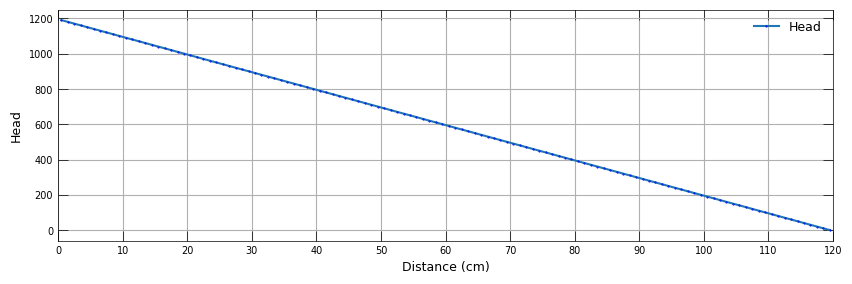

In [24]:
# Obtenemos el objeto con la información de la discretización espacial
grid = o_gwf.modelgrid

# Coordenadas del centro de celdas para graficación
x, _, _ = grid.xyzcellcenters

with styles.USGSPlot():
    plt.rcParams['font.family'] = 'DeJavu Sans'
    plt.figure(figsize=(10,3))
    plt.plot(x[0], head[0, 0], marker=".", ls ="-", mec="blue", mfc="none", markersize="1", label = 'Head')
    plt.xlim(0, 12)
    plt.xticks(ticks=np.linspace(0, grid.extent[1],13))
    plt.xlabel("Distance (cm)")
    plt.ylabel("Head")
    plt.legend()
    plt.grid()
    plt.show()

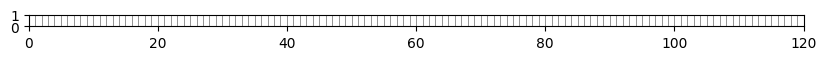

In [35]:
plt.figure(figsize=(10,0.15))
ax = plt.gca()
pmv0 = flopy.plot.PlotMapView(o_gwf, ax=ax)
pmv0.plot_grid(colors='dimgray', lw=0.5)
plt.show()